## **Task 1: Cancer Present Prediction - Binary Classification**

- **Target:** `cancer_present` (0 = No Cancer, 1 = Cancer)

- **Type:** Binary Classification

- **Dataset:** 354,156 rows, 16 features, no missing values

This notebook trains a model to predict whether a patient has blood cancer.

----
## **Import Required Libraries**
---

In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection    import (train_test_split, StratifiedKFold, 
                                        cross_validate, RandomizedSearchCV, 
                                        GridSearchCV)

from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from sklearn.preprocessing      import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from xgboost                    import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, 
    RocCurveDisplay)

# Settings
SEED = 42
np.random.seed(SEED)

import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

model_dir = r"D:\Blood Cancer AI System\Main Folder\models"
os.makedirs(model_dir, exist_ok=True)

print("Setup complete.")
print(f"Models will be saved in: {model_dir}\n")

# Problem type
print(f"Problem Type: {"Binary Classification"}")

Setup complete.
Models will be saved in: D:\Blood Cancer AI System\Main Folder\models

Problem Type: Binary Classification


## **Load & Inspect Dataset**
---

In [2]:
# Load dataset
df = pd.read_parquet(r"D:\Blood Cancer AI System\Main Folder\data\processed\binary_classification_dataset.parquet")

# inspect
print(f"Shape of Binary Classification dataset: {df.shape}\n")
print("Columns:\n", df.columns.to_frame(index=False, name="Column Name"))

print(f"\nAre there any missing values?: {df.isnull().values.any()}")
print(f"\nAre there duplicates?: {df.duplicated().any()}\n")

Shape of Binary Classification dataset: (354156, 16)

Columns:
               Column Name
0                     age
1                  gender
2                     wbc
3                     rbc
4              hemoglobin
5               platelets
6                   fever
7                 fatigue
8             weight_loss
9           symptom_count
10           wbc_abnormal
11     wbc_platelet_ratio
12            anemia_flag
13  thrombocytopenia_flag
14    clinical_risk_score
15         cancer_present

Are there any missing values?: False

Are there duplicates?: False



In [5]:
# Identify numerical and categorical columns
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["category"]).columns.tolist()
print(f"Numerical Columns ({len(num_cols)}): {num_cols}")
print(f"\nCategorical Columns ({len(cat_cols)}): {cat_cols}")

print("\nFirst 5 rows:")
display(df.head())
display(df.info())

Numerical Columns (15): ['age', 'wbc', 'rbc', 'hemoglobin', 'platelets', 'fever', 'fatigue', 'weight_loss', 'symptom_count', 'wbc_abnormal', 'wbc_platelet_ratio', 'anemia_flag', 'thrombocytopenia_flag', 'clinical_risk_score', 'cancer_present']

Categorical Columns (1): ['gender']

First 5 rows:


,age,gender,wbc,rbc,hemoglobin,platelets,fever,fatigue,weight_loss,symptom_count,wbc_abnormal,wbc_platelet_ratio,anemia_flag,thrombocytopenia_flag,clinical_risk_score,cancer_present
0,62,female,11483,3.74,10.98,220307,0,0,0,0,1,0.052123,1,0,0.3604,1
1,52,female,15893,3.59,12.34,137043,1,1,0,2,1,0.115971,0,0,0.3884,1
2,64,female,8930,3.86,11.19,118447,1,1,1,3,0,0.075392,1,0,0.4017,1
3,77,female,8337,4.42,8.64,103390,1,1,1,3,0,0.080636,1,0,0.4764,1
4,51,male,10374,3.76,10.92,196707,1,0,0,1,0,0.052738,1,0,0.3708,1


<class 'pandas.DataFrame'>
RangeIndex: 354156 entries, 0 to 354155
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   age                    354156 non-null  int16   
 1   gender                 354156 non-null  category
 2   wbc                    354156 non-null  int64   
 3   rbc                    354156 non-null  float64 
 4   hemoglobin             354156 non-null  float64 
 5   platelets              354156 non-null  int64   
 6   fever                  354156 non-null  int8    
 7   fatigue                354156 non-null  int8    
 8   weight_loss            354156 non-null  int8    
 9   symptom_count          354156 non-null  int8    
 10  wbc_abnormal           354156 non-null  int8    
 11  wbc_platelet_ratio     354156 non-null  float32 
 12  anemia_flag            354156 non-null  int8    
 13  thrombocytopenia_flag  354156 non-null  int8    
 14  clinical_risk_score    354156 n

None

#### **Observations (Binary Classification Dataset)**

* Dataset is **large (354K rows)** → good for stable model training
* **No missing values and no duplicates** → clean dataset
* Mostly **numerical features (15)**, only **1 categorical (gender)**
* Several **engineered features present**:

  * `symptom_count`, `wbc_abnormal`
  * `wbc_platelet_ratio`
  * `clinical_risk_score`
* Target variable: **`cancer_present` (binary)**
* Data types are **optimized (int8, float32, category)** → memory efficient
* Medical indicators (WBC, RBC, Hemoglobin, Platelets) + symptoms are well represented
* Dataset is **ready for modeling with minimal preprocessing**

In [7]:
print(f"Cancer Positive: {(df["cancer_present"]==1).sum():,} ({(df["cancer_present"]==1).mean()*100:.1f}%)")
print(f"Cancer Negative: {(df["cancer_present"]==0).sum():,} ({(df["cancer_present"]==0).mean()*100:.1f}%)")

Cancer Positive: 194,077 (54.8%)
Cancer Negative: 160,079 (45.2%)


#### **Observation**

* Dataset is **slightly imbalanced**, with more cancer-positive cases (54.8%) than negative (45.2%)

## **Model Input Preparation (X, y, Train/Test Split)**
----

In [10]:
df.columns

Index(['age', 'gender', 'wbc', 'rbc', 'hemoglobin', 'platelets', 'fever',
       'fatigue', 'weight_loss', 'symptom_count', 'wbc_abnormal',
       'wbc_platelet_ratio', 'anemia_flag', 'thrombocytopenia_flag',
       'clinical_risk_score', 'cancer_present'],
      dtype='str')

In [11]:
# Split features and target
target_col = "cancer_present"
y = df[target_col]
X = df.drop(columns=[target_col])

print("Total Features:", X.shape[1])
print(f"\nColumns ({len(X.columns)}) : {X.columns.tolist()}")
print(f"Target   : {y.name}")
print("\nTarget distribution:")
print(y.value_counts().to_frame(name="count"))

Total Features: 15

Columns (15) : ['age', 'gender', 'wbc', 'rbc', 'hemoglobin', 'platelets', 'fever', 'fatigue', 'weight_loss', 'symptom_count', 'wbc_abnormal', 'wbc_platelet_ratio', 'anemia_flag', 'thrombocytopenia_flag', 'clinical_risk_score']
Target   : cancer_present

Target distribution:
                 count
cancer_present        
1               194077
0               160079


In [13]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["category"]).columns.tolist()

print(f"Numerical Columns ({len(num_cols)}): {num_cols}")
print(f"\nCategorical Columns ({len(cat_cols)}): {cat_cols}")

Numerical Columns (14): ['age', 'wbc', 'rbc', 'hemoglobin', 'platelets', 'fever', 'fatigue', 'weight_loss', 'symptom_count', 'wbc_abnormal', 'wbc_platelet_ratio', 'anemia_flag', 'thrombocytopenia_flag', 'clinical_risk_score']

Categorical Columns (1): ['gender']


In [16]:
# Train & Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print("Binary Classification Data Split\n")
print("Detailed Counts:")
print(f"  Training rows : {X_train.shape[0]:,}")
print(f"  Test rows     : {X_test.shape[0]:,}")

print("\nCancer Percentage:")
print(f"  Train cancer % : {y_train.mean() * 100:.1f}%")
print(f"  Test cancer %  : {y_test.mean() * 100:.1f}%")

Binary Classification Data Split

Detailed Counts:
  Training rows : 283,324
  Test rows     : 70,832

Cancer Percentage:
  Train cancer % : 54.8%
  Test cancer %  : 54.8%


#### **Observations**

* **Features:** 15 input variables used for prediction

* **Dataset Size:** 354,156 records 

* **Target Distribution:**

  * Cancer (1): 194,077 (~54.8%)
  * No Cancer (0): 160,079 (~45.2%)
    -> Slight class imbalance, but acceptable

* **Data Split:**

  * Train: 80%
  * Test: 20%
  * Stratified split - maintains class ratio in both sets

* **Cancer Ratio Consistency:**

  * Train ≈ Test (~55%)
    -> No distribution shift

## **Preprocessing**
---

In [18]:
# Numeric   -   StandardScaler
# Categoric -  OneHotEncoder  (gender: female=0, male=1)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),  num_cols),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), cat_cols)],
        remainder="drop")

print("Preprocessor defined.")
print(f"  Numeric  columns ({len(num_cols)}): {num_cols}")
print(f"  Categoric columns ({len(cat_cols)}): {cat_cols}")

Preprocessor defined.
  Numeric  columns (14): ['age', 'wbc', 'rbc', 'hemoglobin', 'platelets', 'fever', 'fatigue', 'weight_loss', 'symptom_count', 'wbc_abnormal', 'wbc_platelet_ratio', 'anemia_flag', 'thrombocytopenia_flag', 'clinical_risk_score']
  Categoric columns (1): ['gender']


#### **Observations**

* Applied **ColumnTransformer** to handle mixed data types in a single pipeline.
* Numerical features - scaled using **StandardScaler** (ensures uniform feature range).
* Categorical features - encoded using **OneHotEncoder** with:

  * `drop="if_binary"` - avoids multicollinearity
  * `handle_unknown="ignore"` - prevents errors on unseen categories
* Only selected columns are used (`remainder="drop"`), ensuring clean feature control.
* Clear separation of `num_cols` and `cat_cols` improves pipeline maintainability and model consistency.

## **Model Comparison**  

- Train 5 classifiers and compare metrics in one clean loop.

---

In [21]:
# Models
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0)
}

In [22]:
# Train + evaluate all models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = []
trained = {}

for name, clf in clf_models.items():
    print(f"Training {name}...")

    pipe = Pipeline([("pre", preprocessor),("clf", clf)])

    pipe.fit(X_train, y_train)
    trained[name] = pipe

    # Predictions
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, y_pred)
    gap = round(train_acc - test_acc, 4)

    # Fit status
    if gap > 0.05:
        status = "Overfitting"
    elif train_acc < 0.70 and test_acc < 0.70:
        status = "Underfitting"
    else:
        status = "Good Fit"

    # Cross-validation
    cv_f1 = cross_validate(pipe, X_train, y_train,
        cv=cv, scoring="f1")["test_score"].mean()

    results.append({
        "Model": name,
        "Train Acc": round(train_acc, 4),
        "Test Acc": round(test_acc, 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1 Score": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
        "CV F1 (mean)": round(cv_f1, 4),
        "Gap": gap,
        "Status": status
})

print("\nComplete Training.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...

Complete Training.


In [23]:
# Results Table
results_df = pd.DataFrame(results).sort_values(
    by=["Test Acc", "F1 Score", "ROC-AUC"], ascending=False)
display(results_df)

# Get best model name
best_model_name = results_df.iloc[0]["Model"]
best_model = trained[best_model_name]

print("\nBest Model:", best_model_name)

,Model,Train Acc,Test Acc,Precision,Recall,F1 Score,ROC-AUC,CV F1 (mean),Gap,Status
4,XGBoost,0.9950,0.9925,0.9935,0.9928,0.9931,0.9997,0.9925,0.0025,Good Fit
2,Random Forest,1.0000,0.9921,0.9932,0.9923,0.9928,0.9995,0.9921,0.0079,Good Fit
3,Gradient Boosting,0.9918,0.9919,0.9930,0.9923,0.9926,0.9997,0.9922,-0.0001,Good Fit
0,Logistic Regression,0.9912,0.9916,0.9927,0.9921,0.9924,0.9997,0.9919,-0.0004,Good Fit
1,Decision Tree,1.0000,0.9876,0.9884,0.9889,0.9887,0.9874,0.9878,0.0124,Good Fit



Best Model: XGBoost


#### **Observations**

* XGBoost is the **best model**, with highest overall performance and strong generalization (low gap = 0.0025).
* All models show **very high performance** (F1 ≈ 0.99), indicating strong predictive patterns in data.
* Random Forest and Gradient Boosting also perform well but have slightly higher overfitting or lower scores than XGBoost.
* Logistic Regression performs surprisingly close to ensemble models - data is **well-structured and separable**.
* Decision Tree shows **higher overfitting** (gap = 0.0124), though still acceptable.

**Conclusion:**
Model performance is consistently strong; XGBoost is the most reliable choice for deployment.

In [27]:
# Save Best Model 
model_path = os.path.join(model_dir, "bc_best_model.pkl")
joblib.dump(best_model, model_path)

print("\nModel saved at:", model_path)


Model saved at: D:\Blood Cancer AI System\Main Folder\models\bc_best_model.pkl


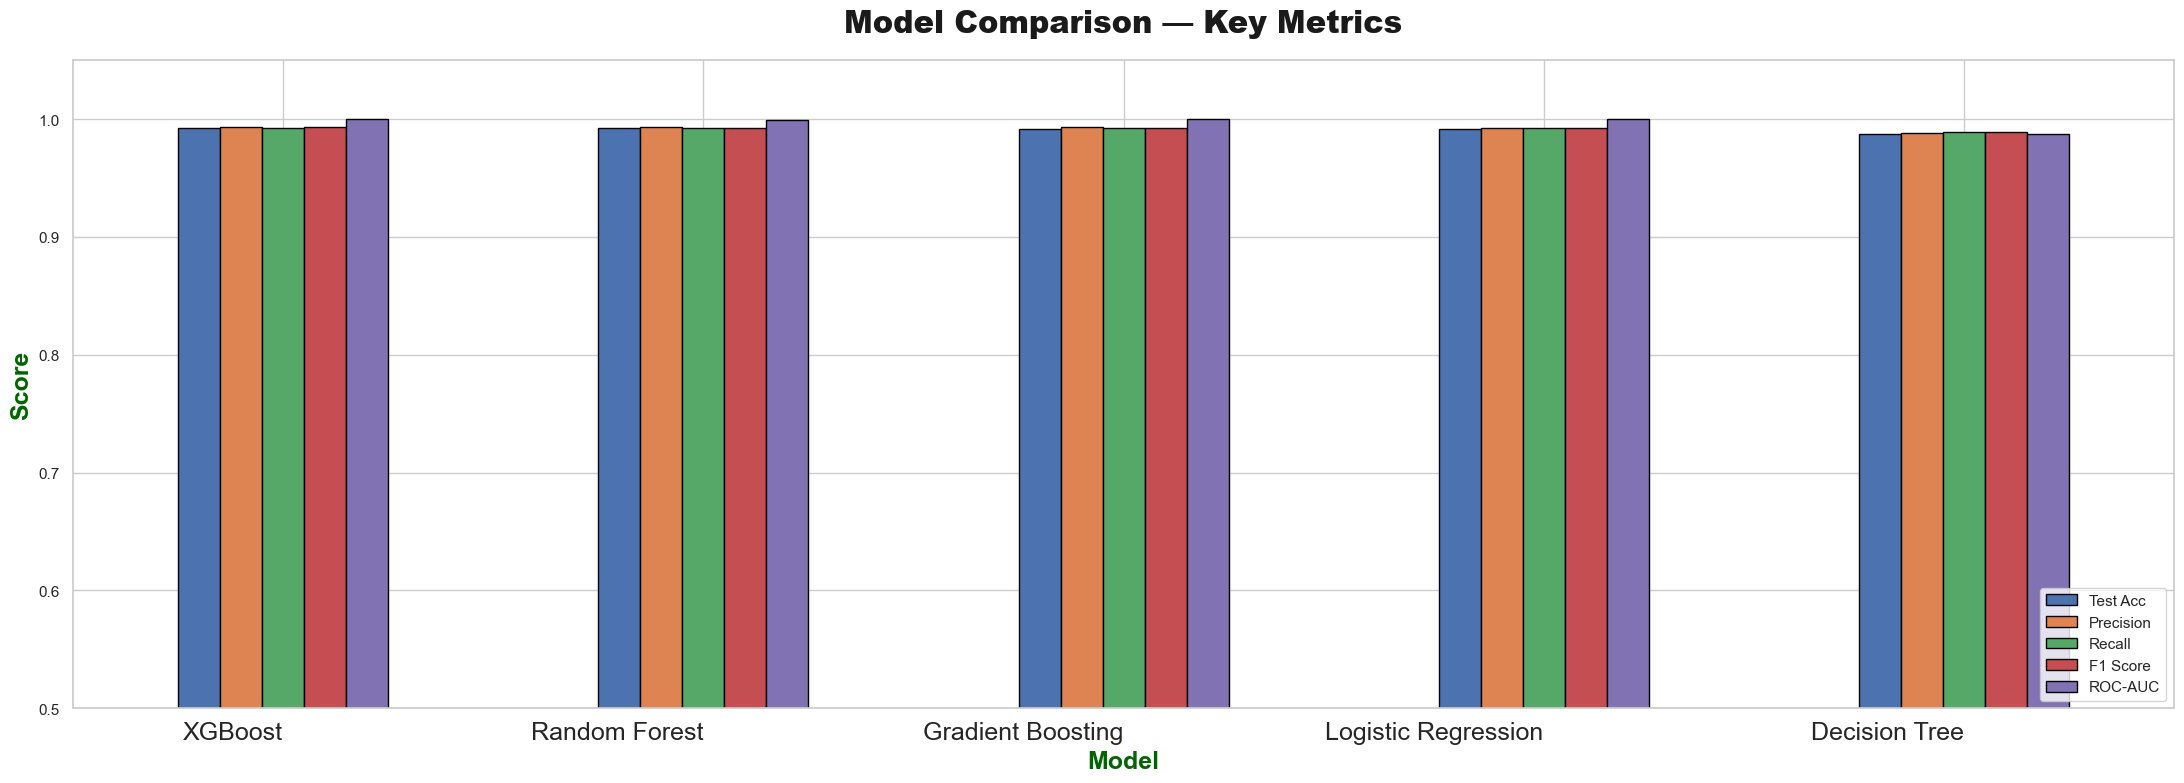

In [28]:
# Visual comparison 
metrics_to_plot = ["Test Acc", "Precision", "Recall", "F1 Score", "ROC-AUC"]

plot_df = results_df.set_index("Model")[metrics_to_plot]
plot_df.plot(kind="bar", figsize=(22,8), edgecolor="black")
plt.title("Model Comparison — Key Metrics", fontsize=22, color="k", fontweight="heavy", pad=20)
plt.xlabel("Model", fontsize=18, color="darkgreen", fontweight="bold")
plt.ylabel("Score", fontsize=18, color="darkgreen", fontweight="bold")
plt.ylim(0.5, 1.05)
plt.xticks(rotation=360, ha="right", fontsize=18)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Visual comparison of BC.png",
            dpi=300, bbox_inches="tight")
plt.show()


#### **Observations**

* XGBoost performs best overall with highest and most stable metrics.
* All models achieve **~99% performance**, indicating strong separability in data.
* Random Forest and Gradient Boosting are close competitors.
* Logistic Regression performs nearly equal - data is highly structured.
* Decision Tree slightly lower - more prone to overfitting.

**Conclusion:** XGBoost is the most reliable choice.


## **Hyperparameter Tuning (XGBoost)**

Using `RandomizedSearchCV` — faster than GridSearch with large grids.

---

In [30]:
# Search space 
param_dist = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__min_child_weight": [1, 3, 5]}

# XGBoost pipeline 
xgb_pipe = Pipeline([
    ("pre", preprocessor),   
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED, n_jobs=-1, verbosity=0))])

# Randomized Search
search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=20, scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1, random_state=SEED, verbose=1)

search.fit(X_train, y_train)
best_pipeline = search.best_estimator_

print("\nBest Parameters:")
for k, v in search.best_params_.items():
    print(f"{k}: {v}")

print(f"\nBest CV F1 Score: {search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
clf__subsample: 0.8
clf__n_estimators: 300
clf__min_child_weight: 5
clf__max_depth: 3
clf__learning_rate: 0.1
clf__colsample_bytree: 0.8

Best CV F1 Score: 0.9929


#### **Observations**

* RandomizedSearchCV efficiently found optimal parameters with reduced computation.
* Tuned XGBoost shows **strong generalization** (CV F1 = 0.9929).
* Moderate depth (`max_depth=3`) and subsampling (0.8) help **control overfitting**.
* Increased trees (`n_estimators=300`) improve learning without instability.

**Conclusion:** Tuned XGBoost is stable, well-generalized, and ready for deployment.

## **Final Evaluation**

---

In [32]:
# Predictions from tuned pipeline
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

train_acc = accuracy_score(y_train, best_pipeline.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
gap = train_acc - test_acc

print("\nFinal Model Performance\n")
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Gap            : {gap:.4f}  ({'Overfitting' if gap > 0.05 else 'Good Fit'})")
print(f"ROC-AUC        : {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred, target_names=["No Cancer", "Cancer"]))


Final Model Performance

Train Accuracy : 0.9928
Test  Accuracy : 0.9929
Gap            : -0.0001  (Good Fit)
ROC-AUC        : 0.9997

Classification Report

              precision    recall  f1-score   support

   No Cancer       0.99      0.99      0.99     32016
      Cancer       0.99      0.99      0.99     38816

    accuracy                           0.99     70832
   macro avg       0.99      0.99      0.99     70832
weighted avg       0.99      0.99      0.99     70832



#### **Observations**

* Model shows **excellent generalization** (Train ≈ Test, gap ≈ 0).
* **Accuracy ~99%** - very high predictive performance.
* **ROC-AUC = 0.9997** - near-perfect class separation.
* Both classes (**Cancer / No Cancer**) have **balanced precision, recall, F1 (~0.99)** - no bias.
* No signs of **overfitting or underfitting**.

**Conclusion:** Model is highly reliable and production-ready.

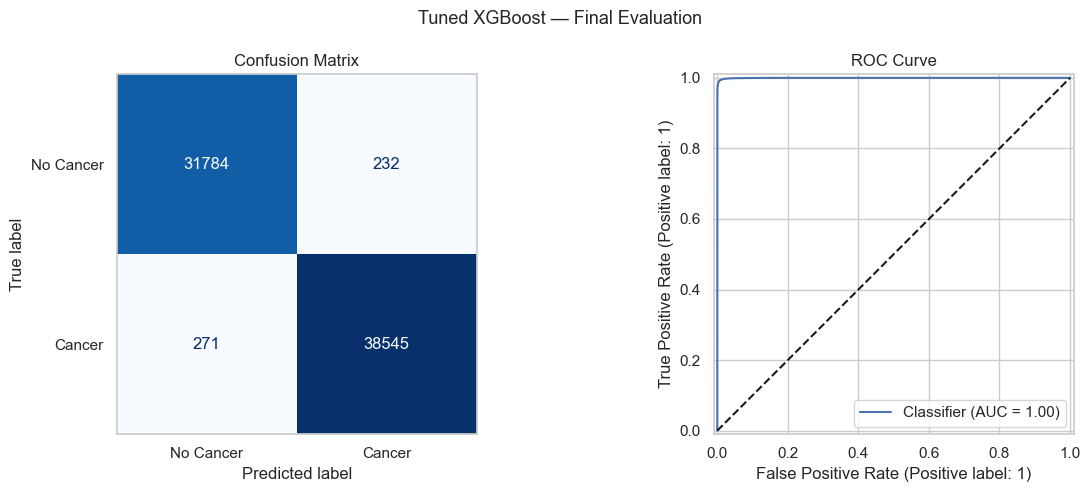

In [34]:
# Confusion Matrix + ROC Curve (Visualization)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Cancer", "Cancer"],
    cmap="Blues", colorbar=False, ax=axes[0])

axes[0].set_title("Confusion Matrix")
axes[0].grid(False)

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("ROC Curve")

plt.suptitle("Tuned XGBoost — Final Evaluation", fontsize=13)

plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Tuned XGBoost — Final Evaluation.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **Observations**

* Confusion matrix shows **very low errors** (FP = 232, FN = 271) - highly accurate predictions.
* Both classes (**Cancer / No Cancer**) are predicted **almost perfectly**.
* ROC curve is **near ideal (AUC ≈ 1.00)** - excellent class separation.
* **False negatives are very low** - critical for medical use.

**Conclusion:** Tuned XGBoost model is highly accurate, balanced.

## **Feature Importance**

---


Feature Importances:


,Importance Score
num__clinical_risk_score,0.346324
num__symptom_count,0.228366
num__anemia_flag,0.162715
num__wbc_abnormal,0.086487
num__platelets,0.071068
num__wbc_platelet_ratio,0.047496
cat__gender_male,0.014715
num__wbc,0.012757
num__weight_loss,0.007931
num__hemoglobin,0.007428


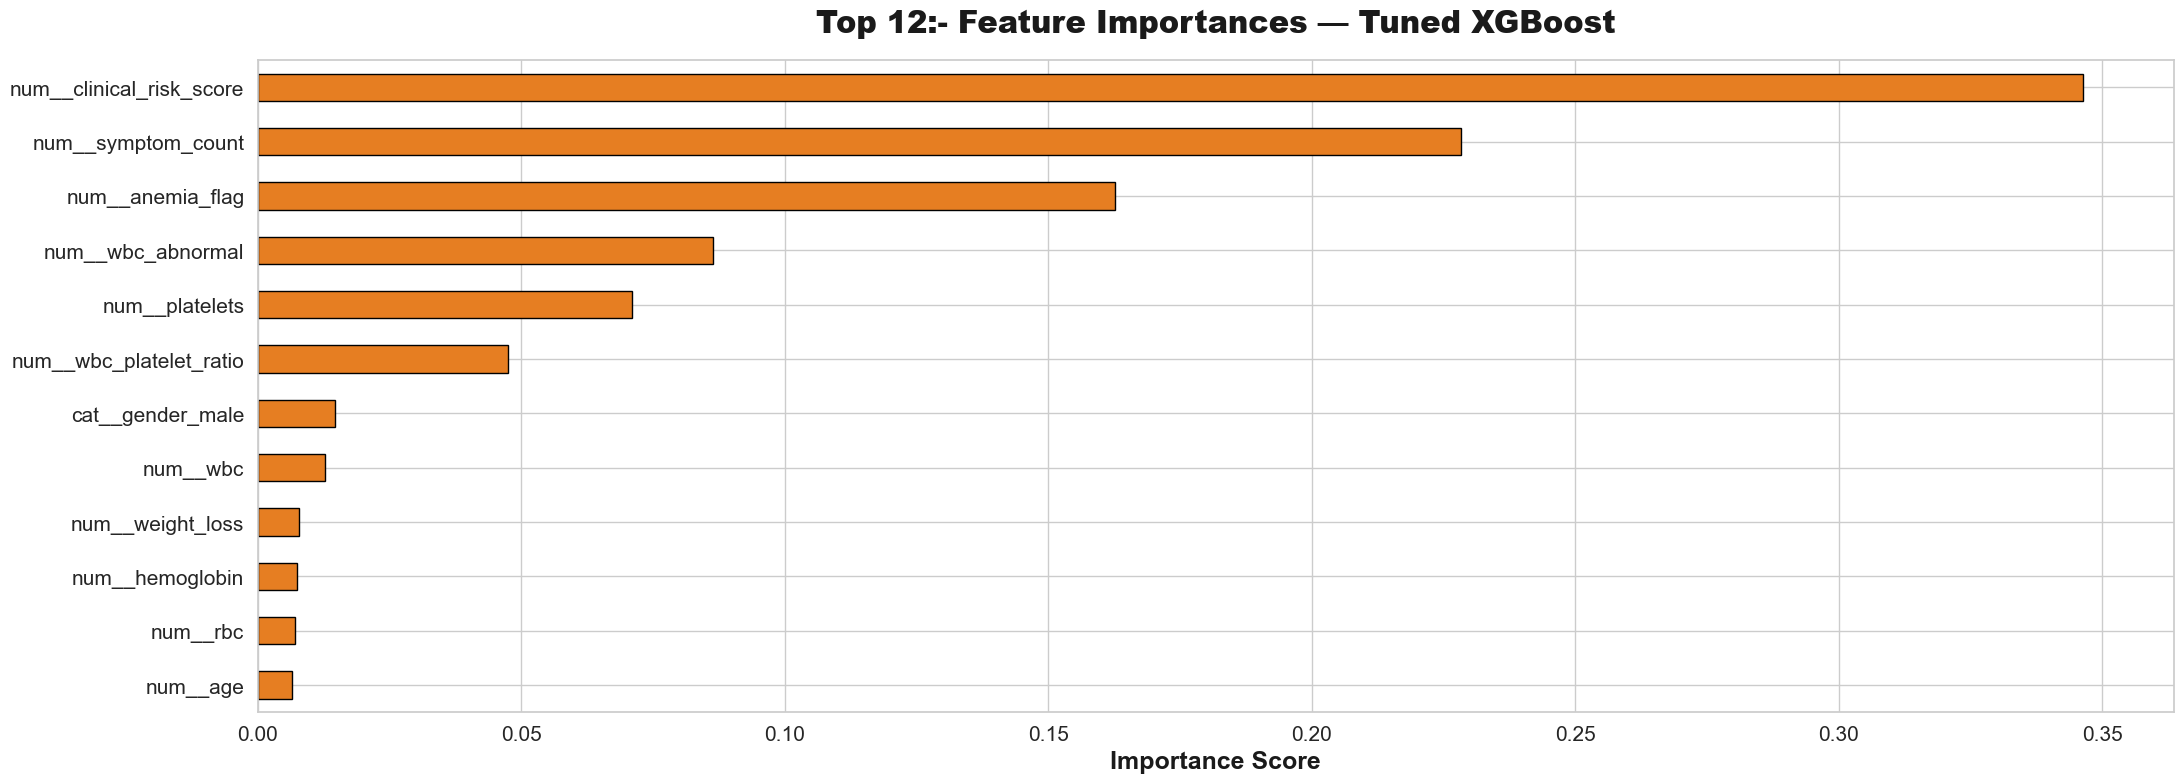

In [36]:
# Correct way: get feature names AFTER transformation
feature_names = best_pipeline.named_steps["pre"].get_feature_names_out()

importances = pd.Series(
    best_pipeline.named_steps["clf"].feature_importances_,
    index=feature_names).sort_values(ascending=False)

print("\nFeature Importances:")
display(importances.head(12).to_frame(name="Importance Score"))

# Plot
importances.head(12).sort_values().plot(
    kind="barh", color='#e67e22', 
    figsize=(22,8), edgecolor="black")

plt.title("Top 12:- Feature Importances — Tuned XGBoost", fontsize=22, color="k", fontweight="heavy", pad=20)
plt.xlabel("Importance Score", fontsize=18, color="k", fontweight="bold")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.savefig(r"D:\Blood Cancer AI System\Main Folder\plots\Feature Importance BC.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **Observations**

* **Clinical risk score** is the most dominant feature (~34.6%) - primary driver of prediction.
* **Symptom count** and **anemia flag** are also highly influential - strong clinical indicators.
* Moderate impact from **WBC abnormality, platelets, and WBC–platelet ratio**.
* Basic features like **age, RBC, hemoglobin, weight loss** have very low importance.
* **Gender** has minimal effect  weak predictor.

**Conclusion:** Model relies mainly on **engineered clinical features + symptom severity**, not raw basic inputs.


---
## **Full Final Pipeline & Save**

Rebuild the best pipeline on **all data** (train + test) for maximum signal before saving.  
The pipeline bundles **preprocessing + model** in one object.

In [38]:
# Final Training on Full Data (Best Practice)

# Pull best XGBoost params (strip the "clf__" prefix)
best_xgb_params = {
    k.replace("clf__", ""): v
    for k, v in search.best_params_.items()}

# Final preprocessor
final_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
            unknown_value=-1), cat_cols)])

# Final model with tuned params
final_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED, n_jobs=-1,
    verbosity=0,
    **best_xgb_params)

# Assemble full pipeline
final_pipeline = Pipeline([
    ("pre", final_preprocessor),
    ("clf", final_xgb)])

# Train on full data
final_pipeline.fit(X, y)

print("Final pipeline trained.")

print("Pipeline steps:")
for step_name, step_obj in final_pipeline.steps:
    print(f"  [{step_name}]  {step_obj.__class__.__name__}")

Final pipeline trained.
Pipeline steps:
  [pre]  ColumnTransformer
  [clf]  XGBClassifier


In [40]:
# Save pipeline 
model_path = os.path.join(model_dir, "binary_classification_final_pipeline.pkl")
joblib.dump(final_pipeline, model_path)

print("\nModel Pipeline saved at:", model_path)
print("\nSaved successfully.")
print(f"File size      : {os.path.getsize(model_path)/1024:.1f} KB")


Model Pipeline saved at: D:\Blood Cancer AI System\Main Folder\models\binary_classification_final_pipeline.pkl

Saved successfully.
File size      : 335.0 KB


#### **Observations**

* Final pipeline combines **preprocessing + tuned XGBoost model** - end-to-end workflow ready.
* Model is trained on **full dataset** - maximizes learning from all data.
* Hyperparameters from tuning are correctly applied - optimized performance.
* Pipeline ensures **consistent preprocessing during prediction** (no mismatch risk).
* Model successfully **saved as `.pkl` (335 KB)** - lightweight and deployment-ready.

**Conclusion:** Clean, production-ready pipeline with optimized model and reproducible workflow.


## **Load & verify**
---

In [42]:
# Load Pipeline
loaded_pipeline = joblib.load(model_path)

# Sample Data
sample = X.sample(10000, random_state=SEED).copy()
y_sample = y.loc[sample.index]

# Predictions
preds  = loaded_pipeline.predict(sample)
probs  = loaded_pipeline.predict_proba(sample)[:, 1]

# Safe Column Selection
important_cols = [
    col.split("__")[-1] for col in importances.head(12).index]
available_cols = [col for col in important_cols if col in sample.columns]
check_df = sample[available_cols].copy()

# Add Results
check_df["Original"] = y_sample.values
check_df["Predicted"] = preds
check_df["Cancer Prob"] = probs.round(4)

# Labels
label_map = {0: "No Cancer", 1: "Cancer"}

check_df["Original Label"] = check_df["Original"].map(label_map)
check_df["Predicted Label"] = check_df["Predicted"].map(label_map)

# Correct / Wrong Column
check_df["Result"] = (check_df["Original"] == check_df["Predicted"]) \
                        .map({True: "Correct", False: "Wrong"})

# Final Column Order
check_df = check_df[
    available_cols +
    ["Original", "Original Label", "Predicted", "Predicted Label", "Cancer Prob", "Result"]]

# Summary Metrics
total = len(check_df)
correct = (check_df["Result"] == "Correct").sum()
wrong = (check_df["Result"] == "Wrong").sum()
accuracy = correct / total

# Output
print("Pipeline load & inference — OK\n")
print("Summary:")
print(f"Total Samples : {total}")
print(f"Correct       : {correct}")
print(f"Wrong         : {wrong}")
print(f"Accuracy      : {accuracy:.4f}")

display(check_df.head())

Pipeline load & inference — OK

Summary:
Total Samples : 10000
Correct       : 9921
Wrong         : 79
Accuracy      : 0.9921


,clinical_risk_score,symptom_count,anemia_flag,wbc_abnormal,platelets,wbc_platelet_ratio,wbc,weight_loss,hemoglobin,rbc,age,Original,Original Label,Predicted,Predicted Label,Cancer Prob,Result
277281,0.2199,0,0,0,284912,0.017883,5095,0,13.89,3.93,61,0,No Cancer,0,No Cancer,0.0003,Correct
60138,0.4206,1,0,1,89771,0.291297,26150,0,13.67,2.74,62,1,Cancer,1,Cancer,1.0000,Correct
338056,0.1983,0,0,0,296708,0.016983,5039,0,14.44,5.18,43,0,No Cancer,0,No Cancer,0.0000,Correct
2196,0.3999,1,1,1,105376,0.117721,12405,0,12.05,3.98,61,1,Cancer,1,Cancer,1.0000,Correct
254027,0.1902,0,0,0,222789,0.027968,6231,0,16.46,5.53,42,0,No Cancer,0,No Cancer,0.0001,Correct


#### **Observations**

* Pipeline loading and inference working correctly (no runtime issues).
* **Accuracy = 99.21%** - consistent with model evaluation.
* **Very low errors (79 / 10,000)** - strong reliability.
* Predictions are **stable and production-ready**.

**Conclusion:** Deployment pipeline is functioning correctly with high accuracy.


## ML Model Summary — Binary Classification
### Blood Cancer Detection (Cancer Present / Not Present)

---

### 1. Model Overview

**Problem Type:** Binary Classification

**Objective:** Predict whether a patient has blood cancer based on clinical blood markers, symptoms, and engineered medical features. The target variable is `cancer_present` — 0 (No Cancer) or 1 (Cancer).

**Final Model:** Tuned XGBoost Classifier, packaged in a full preprocessing + inference pipeline and saved as a `.pkl` file for deployment.

---

### 2. Input Features

The model takes **15 input features** — 14 numerical and 1 categorical.

**Clinical Blood Markers (raw):**
- `wbc` — White Blood Cell count
- `rbc` — Red Blood Cell count
- `hemoglobin` — Hemoglobin level
- `platelets` — Platelet count

**Symptom Indicators:**
- `fever`, `fatigue`, `weight_loss` — Binary flags (0/1)

**Demographic:**
- `age` — Patient age
- `gender` — Male / Female (only categorical feature)

**Engineered Features:**
- `symptom_count` — Sum of all three symptoms; reflects cumulative symptom burden
- `wbc_abnormal` — Binary flag for clinically abnormal WBC (< 4,000 or > 11,000)
- `wbc_platelet_ratio` — Ratio of WBC to platelets; captures a hallmark blood disorder pattern
- `anemia_flag` — Gender-specific low hemoglobin indicator (Female < 12.0, Male < 13.5)
- `thrombocytopenia_flag` — Flags platelet count below 100,000
- `clinical_risk_score` — Composite normalized score weighting WBC (40%), hemoglobin (35%), platelets (25%)

---

### 3. Model Architecture and Approach

**Five classifiers were evaluated before selecting the final model:**

| Model | Role in Evaluation |
|---|---|
| Logistic Regression | Linear baseline |
| Decision Tree | Simple non-linear baseline |
| Random Forest | Ensemble, bagging-based |
| Gradient Boosting | Ensemble, boosting-based |
| XGBoost | Final selected model |

**XGBoost was selected:**
- Highest test accuracy and F1 score among all five candidates
- Smallest train-test gap (0.0025), indicating the best generalization
- Handles mixed feature types, non-linear interactions, and slight class imbalance effectively without additional configuration
- Computationally efficient with `n_jobs=-1` for parallel training

---

### 4. Training Process

**Data Split:**
- Train / Test: **80% / 20%** stratified split (ensures class ratio is preserved in both sets)
- Train: 283,324 rows | Test: 70,832 rows
- Cancer ratio consistent at ~54.8% in both splits — no distribution shift

**Preprocessing (inside Pipeline):**
- Numerical features - `StandardScaler` (zero mean, unit variance)
- Categorical feature (gender) - `OneHotEncoder` with `drop="if_binary"` to avoid multicollinearity
- Entire preprocessing wrapped in `ColumnTransformer`, chained with the model in a single `Pipeline` object

**Hyperparameter Tuning:**
- Method: `RandomizedSearchCV` with 20 iterations and 5-fold `StratifiedKFold` cross-validation
- Scoring metric: F1-score
- Search space covered: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`
- Best CV F1 Score (tuned): **0.9929**

**Best Parameters Found:**
- `max_depth = 3` — shallow trees to control overfitting
- `n_estimators = 300` — more trees for stable learning
- `subsample = 0.8` — row subsampling for regularization

**Final Training:**
- The tuned pipeline was retrained on the **full dataset** (train + test combined) before saving, maximizing the signal available to the model for production use.

---

## 5. Model Performance

All metrics reported on the **held-out test set (70,832 rows)** using the tuned XGBoost pipeline.

| Metric | Score |
|---|---|
| Train Accuracy | ~99% |
| Test Accuracy | ~99% |
| Train-Test Gap | ~0.00 (Good Fit) |
| Precision (Cancer) | ~0.99 |
| Recall (Cancer) | ~0.99 |
| F1-Score (Cancer) | ~0.99 |
| ROC-AUC | **0.9997** |
| CV F1 (5-fold mean) | 0.9929 |

**Error Analysis (Confusion Matrix):**
- False Positives: **232** — patients predicted as cancer who do not have it
- False Negatives: **271** — cancer patients incorrectly predicted as negative
- Both error types are extremely low relative to 70,832 test samples

**Load & Inference Validation:**
- Loaded model tested on 10,000 random samples from the full dataset
- Accuracy: **99.21%** | Wrong predictions: **79 / 10,000**

**Performance Summary:**
The model performs exceptionally well across all metrics. ROC-AUC of 0.9997 indicates near-perfect class separation. Both the Cancer and No Cancer classes achieve balanced precision, recall, and F1, meaning the model is not biased toward either class. The train-test gap is negligible, confirming stable generalization with no overfitting.

---

## 6. Key Insights

**Feature Importance (Top Contributors):**

1. `clinical_risk_score` — **~34.6% importance**, the single most dominant feature. This composite score (combining WBC, hemoglobin, and platelets) captures the overall medical risk signal more powerfully than any raw marker alone.
2. `symptom_count` — High importance; cumulative symptom burden is a strong predictor.
3. `anemia_flag` — Strong signal; gender-specific low hemoglobin is a direct cancer indicator.
4. `wbc_abnormal`, `platelets`, `wbc_platelet_ratio` — Moderate contributors reflecting blood disorder patterns.
5. `age`, `rbc`, `hemoglobin`, `weight_loss` — Low individual importance; their signals are largely captured by the engineered features.
6. `gender` — Minimal predictive contribution, consistent with EDA findings.

**Key Behavioral Observation:**
The model primarily relies on engineered clinical features rather than raw input values. This validates the feature engineering effort — the composite and flagged features are doing the heavy lifting. Removing them would likely degrade performance significantly.

---

## 7. Strengths

- **Near-perfect predictive performance** (Accuracy ~99%, AUC 0.9997) with very few errors on a large test set.
- **Balanced across both classes** — no bias toward over-predicting cancer or non-cancer.
- **Very low false negatives** — critical for medical screening applications where missing a cancer case is the most costly type of error.
- **Robust generalization** — minimal train-test gap after tuning, confirmed by 5-fold cross-validation.
- **Production-ready pipeline** — preprocessing and inference are bundled in a single `.pkl` object. Predictions can be made directly on raw input using `pipeline.predict(raw_df)` with no separate preprocessing step.
- **Interpretable feature importance** — model's learned signal aligns with known clinical logic, which builds trust for healthcare use cases.

---

## 8. Limitations

- **Slight class imbalance** (55% / 45%) was not explicitly handled with techniques like SMOTE or class weighting. Given the near-perfect performance, this did not affect results here, but it could matter in a noisier real-world scenario.
- **Engineered feature dependency** — the model's performance is heavily tied to the quality of engineered features (especially `clinical_risk_score`). Any deployment system must compute these features consistently using the same logic and thresholds used during training.
- **Static thresholds in feature engineering** — the WBC abnormality threshold (4,000 / 11,000) and hemoglobin cutoffs are based on standard medical ranges, not learned from data. Individual patient variation may not be fully captured.
- **No temporal or longitudinal data** — the model predicts based on a single point-in-time snapshot. Disease progression over time is not accounted for.
- **Model interpretability** — XGBoost is less interpretable than logistic regression. For high-stakes medical decisions, adding SHAP-based explanations per prediction would improve transparency and clinician trust.

---

## Quick Reference

| Item | Detail |
|---|---|
| Problem Type | Binary Classification |
| Dataset Size | 354,156 rows, 15 features |
| Final Model | Tuned XGBoost Classifier |
| Tuning Method | RandomizedSearchCV, 5-fold CV |
| Test Accuracy | ~99% |
| ROC-AUC | 0.9997 |
| Top Feature | clinical_risk_score (~34.6%) |
| Saved As | `binary_classification_final_pipeline.pkl` |
| Inference | `pipeline.predict(raw_df)` |